SỬ DỤNG PYTHON 3.12 TRÊN KAGGLE ĐỂ TEST

In [1]:
!pip install -q transformers underthesea
print("✅ Đã cài đặt xong thư viện!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.7 MB/s eta 0:00:00
✅ Đã cài đặt xong thư viện!


In [2]:
import os
import pandas as pd
import torch
from transformers import AutoTokenizer, RobertaForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm.auto import tqdm

print("🔍 Đang rà quét hệ thống Kaggle để tìm dữ liệu và model...")
test_path = None
sentiment_model_path = None
topic_model_path = None

# Tự động quét tìm đường dẫn
for root, dirs, files in os.walk('/kaggle/input'):
    if 'test_clean_PhoBERT.csv' in files:
        test_path = os.path.join(root, 'test_clean_PhoBERT.csv')
    if 'config.json' in files:
        if 'sentiment_model' in root:
            sentiment_model_path = root
        elif 'topic_model' in root:
            topic_model_path = root

if not all([test_path, sentiment_model_path, topic_model_path]):
    raise FileNotFoundError(f"❌ THIẾU FILE! Hãy kiểm tra lại phần Add Data.\n- Test: {test_path}\n- Sentiment: {sentiment_model_path}\n- Topic: {topic_model_path}")

print("✅ Đã chốt tọa độ thành công!")
print(f" - Sentiment Model: {sentiment_model_path}")
print(f" - Topic Model: {topic_model_path}")

print("\n⏳ Đang nạp hệ thống phân tích kép vào GPU...")
tokenizer = AutoTokenizer.from_pretrained(sentiment_model_path, local_files_only=True)

model_sentiment = RobertaForSequenceClassification.from_pretrained(sentiment_model_path, local_files_only=True).to("cuda")
model_sentiment.eval()

model_topic = RobertaForSequenceClassification.from_pretrained(topic_model_path, local_files_only=True).to("cuda")
model_topic.eval()

print("✅ Lõi PhoBERT đã sẵn sàng 100%!")

🔍 Đang rà quét hệ thống Kaggle để tìm dữ liệu và model...
✅ Đã chốt tọa độ thành công!
 - Sentiment Model: /kaggle/input/datasets/conbobietbay/phobert-feedback-models/models/sentiment_model
 - Topic Model: /kaggle/input/datasets/conbobietbay/phobert-feedback-models/models/topic_model

⏳ Đang nạp hệ thống phân tích kép vào GPU...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Lõi PhoBERT đã sẵn sàng 100%!


In [3]:
print("📥 Đang đọc dữ liệu Test...")
df_test = pd.read_csv(test_path).dropna(subset=['clean_text_PhoBERT'])

texts = df_test['clean_text_PhoBERT'].tolist()
true_sentiments = df_test['sentiment'].tolist()
true_topics = df_test['topic'].tolist()

pred_sentiments = []
pred_topics = []

print(f"🚀 Bắt đầu chấm điểm {len(texts)} bài thi...")
for text in tqdm(texts):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=256).to("cuda")
    
    with torch.no_grad():
        out_s = model_sentiment(**inputs)
        out_t = model_topic(**inputs)
        
        pred_s_idx = torch.argmax(out_s.logits, dim=1).item()
        pred_t_idx = torch.argmax(out_t.logits, dim=1).item()
        
        # Ánh xạ từ Index của GPU về Nhãn gốc
        label_s = int(model_sentiment.config.id2label[pred_s_idx])
        label_t = int(model_topic.config.id2label[pred_t_idx])
        
        pred_sentiments.append(label_s)
        pred_topics.append(label_t)

# Gắn kết quả dự đoán vào dataframe
df_test['pred_sentiment'] = pred_sentiments
df_test['pred_topic'] = pred_topics

print("✅ Hoàn tất quá trình dự đoán!")

📥 Đang đọc dữ liệu Test...
🚀 Bắt đầu chấm điểm 3166 bài thi...


  0%|          | 0/3166 [00:00<?, ?it/s]

✅ Hoàn tất quá trình dự đoán!


🏆 BÁO CÁO THÀNH TÍCH PHOBERT - CẢM XÚC
                precision    recall  f1-score   support

  Tiêu cực (0)       0.94      0.97      0.96      1409
Trung tính (1)       0.73      0.46      0.56       167
  Tích cực (2)       0.95      0.96      0.96      1590

      accuracy                           0.94      3166
     macro avg       0.87      0.80      0.83      3166
  weighted avg       0.94      0.94      0.94      3166


🏆 BÁO CÁO THÀNH TÍCH PHOBERT - CHỦ ĐỀ
                    precision    recall  f1-score   support

    Giảng viên (0)       0.94      0.94      0.94      2290
  Chương trình (1)       0.77      0.80      0.78       572
Cơ sở vật chất (2)       0.94      0.94      0.94       145
          Khác (3)       0.62      0.47      0.53       159

          accuracy                           0.89      3166
         macro avg       0.82      0.79      0.80      3166
      weighted avg       0.89      0.89      0.89      3166



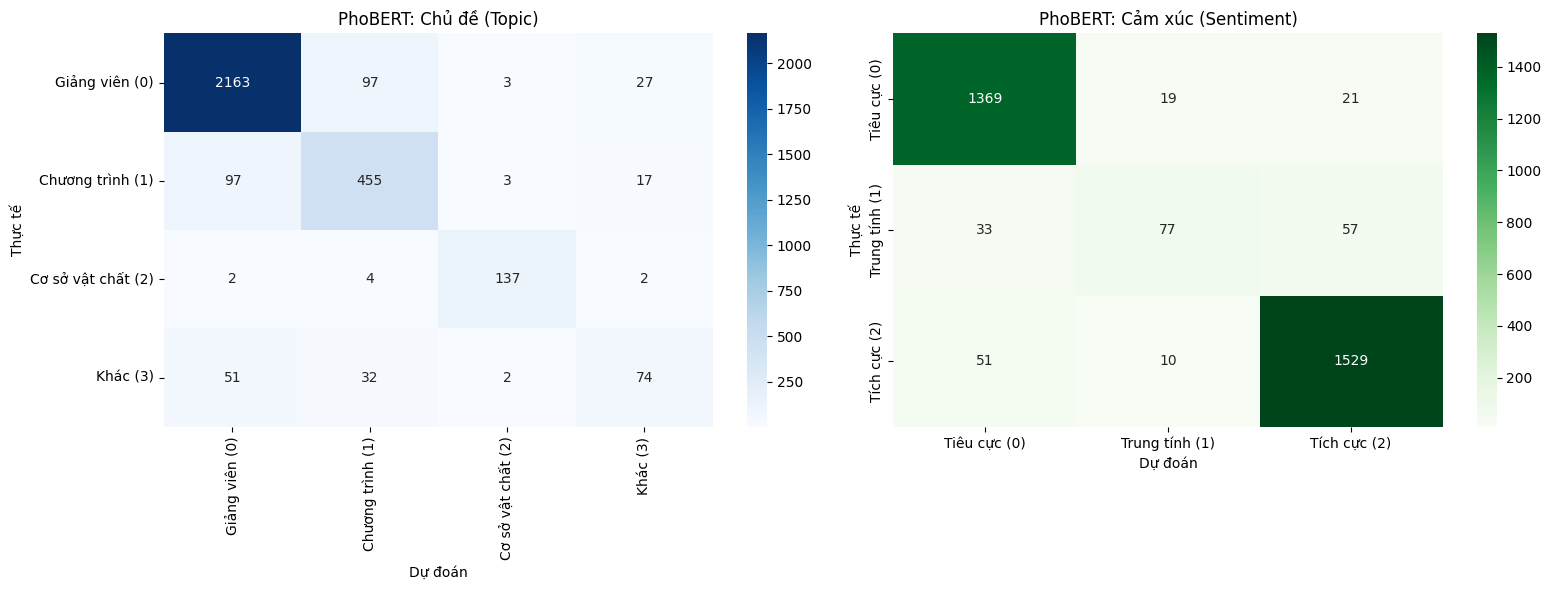

✅ Đã lưu bảng số liệu và ảnh đồ thị!


In [4]:
out_dir = "/kaggle/working/"
sentiment_labels = ['Tiêu cực (0)', 'Trung tính (1)', 'Tích cực (2)']
topic_labels = ['Giảng viên (0)', 'Chương trình (1)', 'Cơ sở vật chất (2)', 'Khác (3)']

print("=========================================")
print("🏆 BÁO CÁO THÀNH TÍCH PHOBERT - CẢM XÚC")
print("=========================================")
print(classification_report(true_sentiments, pred_sentiments, target_names=sentiment_labels))

print("\n=========================================")
print("🏆 BÁO CÁO THÀNH TÍCH PHOBERT - CHỦ ĐỀ")
print("=========================================")
print(classification_report(true_topics, pred_topics, target_names=topic_labels))

# Xuất CSV
pd.DataFrame(classification_report(true_sentiments, pred_sentiments, target_names=sentiment_labels, output_dict=True)).transpose().round(4).to_csv(os.path.join(out_dir, "phobert_sentiment_report.csv"), encoding='utf-8-sig')
pd.DataFrame(classification_report(true_topics, pred_topics, target_names=topic_labels, output_dict=True)).transpose().round(4).to_csv(os.path.join(out_dir, "phobert_topic_report.csv"), encoding='utf-8-sig')

# Vẽ Ma Trận Nhầm Lẫn
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(confusion_matrix(true_topics, pred_topics), annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=topic_labels, yticklabels=topic_labels)
ax[0].set_title('PhoBERT: Chủ đề (Topic)')
ax[0].set_xlabel('Dự đoán')
ax[0].set_ylabel('Thực tế')

sns.heatmap(confusion_matrix(true_sentiments, pred_sentiments), annot=True, fmt='d', cmap='Greens', ax=ax[1], xticklabels=sentiment_labels, yticklabels=sentiment_labels)
ax[1].set_title('PhoBERT: Cảm xúc (Sentiment)')
ax[1].set_xlabel('Dự đoán')
ax[1].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()
fig.savefig(os.path.join(out_dir, "phobert_confusion_matrix.png"))
print("✅ Đã lưu bảng số liệu và ảnh đồ thị!")

In [5]:
# Lọc những câu sai ít nhất 1 trong 2 nhãn
mask_error = (df_test['sentiment'] != df_test['pred_sentiment']) | (df_test['topic'] != df_test['pred_topic'])
df_errors = df_test[mask_error].copy()

# Phiên dịch nhãn
df_errors['sentiment_label'] = df_errors['sentiment'].map({0: 'Tiêu cực', 1: 'Trung tính', 2: 'Tích cực'})
df_errors['pred_sentiment_label'] = df_errors['pred_sentiment'].map({0: 'Tiêu cực', 1: 'Trung tính', 2: 'Tích cực'})
df_errors['topic_label'] = df_errors['topic'].map({0: 'Giảng viên', 1: 'Chương trình', 2: 'Cơ sở vật chất', 3: 'Khác'})
df_errors['pred_topic_label'] = df_errors['pred_topic'].map({0: 'Giảng viên', 1: 'Chương trình', 2: 'Cơ sở vật chất', 3: 'Khác'})

# Tạo thêm cột trống để bạn tự phân tích lỗi trên Excel
df_errors['Nguyen_nhan_sai'] = ""

out_errors = os.path.join(out_dir, "phobert_all_errors.csv")
cols_to_save = ['clean_text_PhoBERT', 'sentiment_label', 'pred_sentiment_label', 'topic_label', 'pred_topic_label', 'Nguyen_nhan_sai']
df_errors[cols_to_save].to_csv(out_errors, index=False, encoding='utf-8-sig')

print("=========================================")
print(f"👉 Tổng số câu PhoBERT bị 'lật kèo': {len(df_errors)}")
print(f"✅ Đã xuất TOÀN BỘ danh sách câu sai ra file CSV để làm báo cáo.")
print("=========================================")

👉 Tổng số câu PhoBERT bị 'lật kèo': 484
✅ Đã xuất TOÀN BỘ danh sách câu sai ra file CSV để làm báo cáo.
